<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">📊 CARA KERJA LSE DAN GRADIENT DESCENT PADA DATA DIABETES (REGRESI)</h1>**

🔗 [Data Diabetes Kaggle](https://www.kaggle.com/datasets/saurabh00007/diabetescsv)

<hr style="border: 4px solid #2e7d32;">

In [ ]:
# ===============================================================
# 📦 IMPORT LIBRARIES
# ===============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import kagglehub
import os

# ===============================================================
# 📥 DOWNLOAD DATASET DARI KAGGLE
# ===============================================================
print("🔽 Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("saurabh00007/diabetescsv")

# Cari file CSV di folder yang diunduh
csv_path = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

if csv_path:
    print(f"✅ Dataset ditemukan: {os.path.basename(csv_path)}")
else:
    raise FileNotFoundError("❌ Tidak ada file CSV ditemukan dalam folder dataset.")

# ===============================================================
# 📂 LOAD DATA KE DATAFRAME
# ===============================================================
df = pd.read_csv(csv_path)

print("\n=================== 🧾 5 Data Pertama ===================")
print(df.head())

print("\n=================== ℹ️ Informasi Data ===================")
df.info()

print("\n=================== 🔍 Statistik Deskriptif ===================")
print(df.describe())

🔽 Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'diabetescsv' dataset.
✅ Dataset ditemukan: diabetes.csv

=================== 🧾 5 Data Pertama ===================
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

=================== ℹ️ Informasi Data ===================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7

In [ ]:
print("========== Data Cleaning - (Mengganti 0 dengan NaN) ==========")
cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Salin data saat ini ke dalam variabel df_cleaned
df_cleaned = df.copy()
df_cleaned[cols_to_clean] = df_cleaned[cols_to_clean].replace(0, np.nan)

# Buang baris yang memiliki missing value pada variabel df_cleaned
df_cleaned = df_cleaned.dropna()
print(f"Ukuran data asli: {df.shape}")
print(f"Ukuran data setelah dibersihkan (dibuang NaN): {df_cleaned.shape}")

========== Data Cleaning - (Mengganti 0 dengan NaN) ==========
Ukuran data asli: (768, 9)
Ukuran data setelah dibersihkan (dibuang NaN): (392, 9)


In [ ]:
print("========== Mempersiapkan X dan y ==========")
# Variabel "y" untuk menyimpan value BMI setelah cleaning
y = df_cleaned['BMI']
# Variabel "x" untuk menyimpan fitur lain selain BMI dan Outcome(label klasifikasi)
X = df_cleaned.drop(['BMI', 'Outcome'], axis=1)

print(f"Fitur X (shape): {X.shape}")
print(f"Target y (shape): {y.shape}")

print("\n========== Melakukan Scaling Fitur (StandardScaler) ==========")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Menghitung mean dan std milik X lalu mengubah nilai yg ada pada X sesuai hasil scaler
y_np = y.values # Ubah y jadi numpy array

# Penambahan kolom intercept (bias) ke X yang sudah di-scale
X_scaled_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
print(f"Shape X_scaled_b (dengan intercept): {X_scaled_b.shape}")

========== Mempersiapkan X dan y ==========
Fitur X (shape): (392, 7)
Target y (shape): (392,)

========== Melakukan Scaling Fitur (StandardScaler) ==========
Shape X_scaled_b (dengan intercept): (392, 8)


In [ ]:
print("\n========== Metode 1 - Normal Equation(Least Square Error) ==========")
# Formula: theta = (X_b.T * X_b)^-1 * X_b.T * y
# Formula untuk mencari theta tersebut di jalankan untuk mendapatkan nilai theta terbaik
theta_best = np.linalg.inv(X_scaled_b.T.dot(X_scaled_b)).dot(X_scaled_b.T).dot(y_np)
print("Koefisien (theta) dari Normal Equation:")
print(theta_best)


========== Metode 1 - Normal Equation(Least Square Error) ==========
Koefisien (theta) dari Normal Equation:
[33.08622449 -0.67579496  0.17580613  1.30976601  4.27131161  0.66852829
  0.37315473 -0.39753231]


In [ ]:
print("\n========== Metode 2 - Gradient Descent ==========")
learning_rate = 0.1
n_iterations = 1000
m = len(y_np) # Jumlah data training

# Inisialisasi theta dengan nol
theta_gd = np.zeros(X_scaled_b.shape[1])

cost_history = []

for iteration in range(n_iterations):
    # 1. Hitung prediksi
    predictions = X_scaled_b.dot(theta_gd)
    # 2. Hitung error
    errors = predictions - y_np
    # 3. Hitung gradien
    gradients = (1/m) * X_scaled_b.T.dot(errors)
    # 4. Update theta
    theta_gd = theta_gd - learning_rate * gradients

    # (Opsional) Hitung cost
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)

print("Koefisien (theta) dari Gradient Descent:")
print(theta_gd)

print(f"\nCost awal (MSE): {cost_history[0]}")
print(f"Cost akhir (MSE) setelah {n_iterations} iterasi: {cost_history[-1]}")


========== Metode 2 - Gradient Descent ==========
Koefisien (theta) dari Gradient Descent:
[33.08622449 -0.67579496  0.17580613  1.30976601  4.27131161  0.66852829
  0.37315473 -0.39753231]

Cost awal (MSE): 571.9801275510204
Cost akhir (MSE) setelah 1000 iterasi: 12.442440451043948


In [ ]:
if theta_best is not None:
    print("\n========== Perbandingan Koefisien ==========")
    # List nama fitur + Intercept
    feature_names = ['Intercept'] + list(X.columns)
    comparison = pd.DataFrame({
        'Feature': feature_names,
        'Normal_Equation': theta_best,
        'Gradient_Descent': theta_gd
    })
    print(comparison)
    print("\nCatatan: Hasilnya seharusnya sangat mirip.")


========== Perbandingan Koefisien ==========
                    Feature  Normal_Equation  Gradient_Descent
0                 Intercept        33.086224         33.086224
1               Pregnancies        -0.675795         -0.675795
2                   Glucose         0.175806          0.175806
3             BloodPressure         1.309766          1.309766
4             SkinThickness         4.271312          4.271312
5                   Insulin         0.668528          0.668528
6  DiabetesPedigreeFunction         0.373155          0.373155
7                       Age        -0.397532         -0.397532

Catatan: Hasilnya seharusnya sangat mirip.


## Evaluasi


========== 1. Evaluasi Model ==========
R-squared (R2) score: 0.4948
(R-squared mengukur seberapa baik model 'fit' dengan data. 1.0 sempurna, 0.0 tidak lebih baik dari menebak rata-rata.)

========== 2. Membuat Visualisasi: cost_history ==========


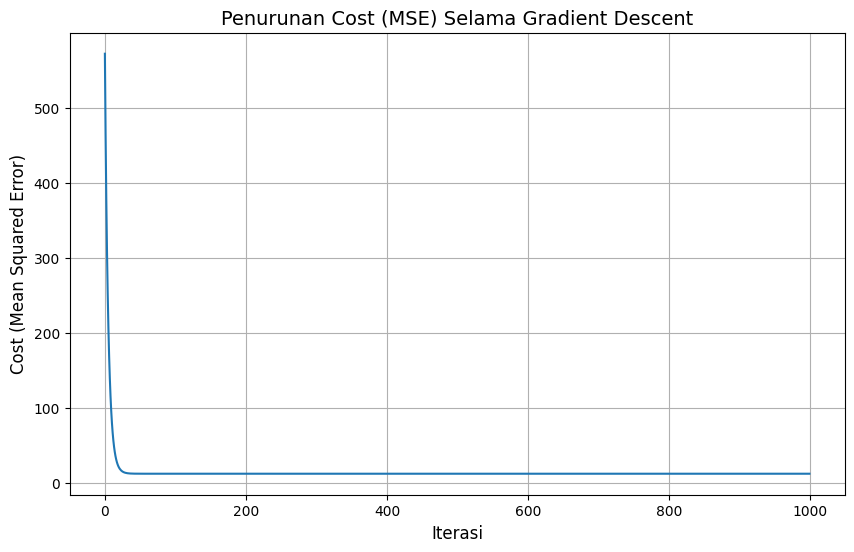

========== 3. Membuat Visualisasi: actual_vs_predicted ==========


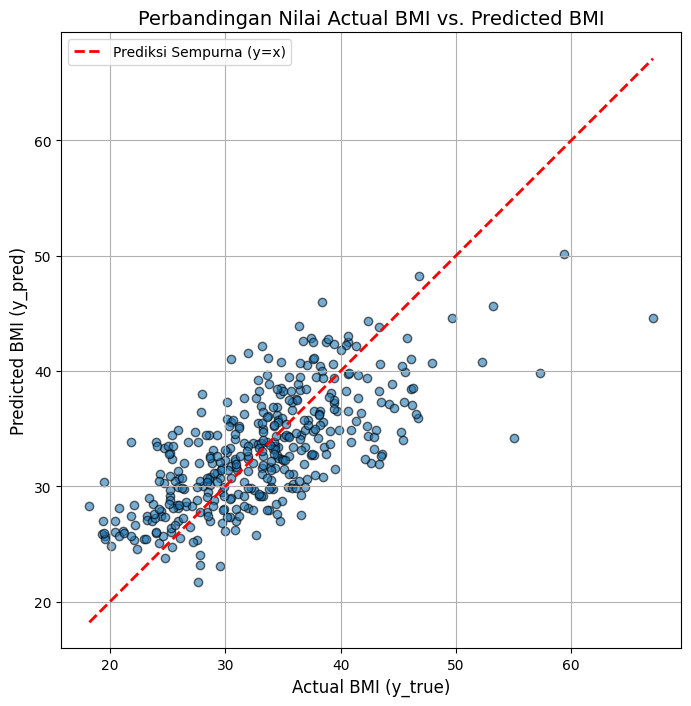

========== 4. Membuat Visualisasi - feature_importance ==========


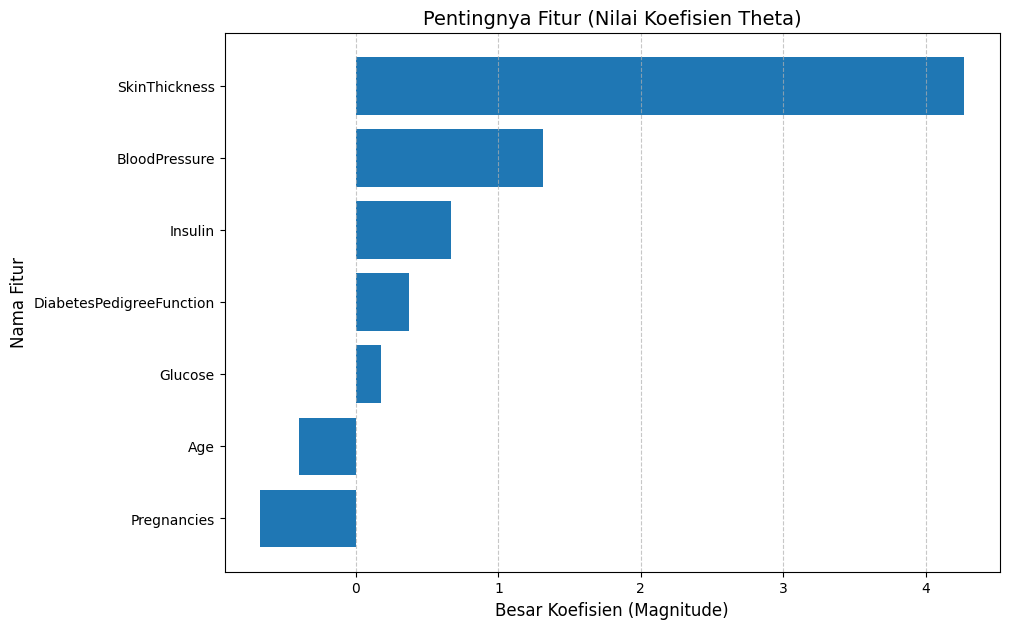

In [ ]:
# ========== 1. Perhitungan Tambahan: Evaluasi Model (R-squared) -==========--
print("\n========== 1. Evaluasi Model ==========")
# Buat prediksi menggunakan theta final
predictions = X_scaled_b.dot(theta_gd)

# Hitung R-squared
r2 = r2_score(y_np, predictions)
print(f"R-squared (R2) score: {r2:.4f}")
print("(R-squared mengukur seberapa baik model 'fit' dengan data. 1.0 sempurna, 0.0 tidak lebih baik dari menebak rata-rata.)")


# ========== 2. Visualisasi 1: Penurunan Cost (Learning Curve) ==========
print("\n========== 2. Membuat Visualisasi: cost_history ==========")
# Buat figur baru
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.title("Penurunan Cost (MSE) Selama Gradient Descent", fontsize=14)
plt.xlabel("Iterasi", fontsize=12)
plt.ylabel("Cost (Mean Squared Error)", fontsize=12)
plt.grid(True)
plt.show()

# ========== 3. Visualisasi 2: Actual vs. Predicted ==========
print("========== 3. Membuat Visualisasi: actual_vs_predicted ==========")
# Buat figur baru
plt.figure(figsize=(8, 8))
plt.scatter(y_np, predictions, alpha=0.6, edgecolors='k')
# Buat garis diagonal (y=x) sebagai referensi
line_min = min(np.min(y_np), np.min(predictions))
line_max = max(np.max(y_np), np.max(predictions))
plt.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Prediksi Sempurna (y=x)')
plt.title("Perbandingan Nilai Actual BMI vs. Predicted BMI", fontsize=14)
plt.xlabel("Actual BMI (y_true)", fontsize=12)
plt.ylabel("Predicted BMI (y_pred)", fontsize=12)
plt.legend()
plt.axis('equal') # Pastikan skala x dan y sama
plt.grid(True)
plt.show()

# ========== 4. Visualisasi 3: Pentingnya Fitur (Koefisien Theta) ==========
print("========== 4. Membuat Visualisasi - feature_importance ==========")
# Ambil nama fitur dari 'X'
feature_names = list(X.columns)
theta_features = theta_gd[1:] # Ambil semua theta kecuali intercept

# Buat DataFrame untuk sorting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': theta_features
}).sort_values(by='Coefficient', ascending=True) # Urutkan

# visualisasi fitur dengan besar koefisien
plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Pentingnya Fitur (Nilai Koefisien Theta)", fontsize=14)
plt.xlabel("Besar Koefisien (Magnitude)", fontsize=12)
plt.ylabel("Nama Fitur", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">📊 Penjelasan Inti Algoritma: LSE dan Gradient Descent pada Data Diabetes (Regresi)</h1>**

<hr style="border: 4px solid #2e7d32;">


## 🎯 Tujuan Utama
Kode ini bertujuan untuk **memprediksi nilai BMI (Body Mass Index)** berdasarkan fitur-fitur lain dari dataset *Diabetes Kaggle* seperti `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `Age`.

Model yang digunakan adalah **Regresi Linear**, yang mencari garis (atau bidang) terbaik untuk memprediksi nilai `y` dari `X`.


---

## 🧹 1. Persiapan dan Pembersihan Data
1. Dataset diunduh dari Kaggle: `saurabh00007/diabetescsv`.
2. Nilai `0` pada kolom tertentu (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) diganti dengan `NaN` karena secara medis nilai tersebut tidak valid.
3. Baris yang memiliki nilai `NaN` dihapus.
4. Fitur (`X`) terdiri dari semua kolom kecuali `BMI` dan `Outcome`.
5. Target (`y`) adalah kolom `BMI`.

---

## ⚙️ 2. Standardisasi Data
Agar semua fitur berada dalam skala yang sama, digunakan **StandardScaler** dari scikit-learn.

- Setiap fitur diubah agar memiliki **mean = 0** dan **standard deviation = 1**.
- Ditambahkan kolom **intercept (bias)** ke dalam `X` untuk memperhitungkan konstanta dalam regresi.

---

## 📘 3. Metode 1 — Normal Equation (Least Square Error / LSE)
**Konsep Utama:**
Mencari solusi *analitik* (langsung) untuk parameter model (`θ`) yang meminimalkan *error kuadrat total*.

<p align="center">
  <b>θ = (XᵀX)<sup>-1</sup>Xᵀy</b>
</p>

- Persamaan ini menghasilkan nilai `θ` optimal tanpa perlu iterasi.
- Cocok untuk dataset kecil hingga menengah.

**Kelebihan:**
✅ Akurat dan tidak butuh pengaturan parameter.

**Kekurangan:**
⚠️ Lambat dan mahal komputasi untuk dataset besar (karena melibatkan invers matriks).

---

## 🔁 4. Metode 2 — Gradient Descent
**Konsep Utama:**
Pendekatan *numerik iteratif* untuk menemukan nilai `θ` terbaik dengan cara menurunkan fungsi *cost* sedikit demi sedikit.

Langkah-langkahnya:
1. Inisialisasi `θ = 0`
2. Untuk setiap iterasi:
   - Hitung prediksi:  
     <p align="center"><b>ŷ = Xθ</b></p>
   - Hitung error:  
     <p align="center"><b>e = ŷ − y</b></p>
   - Hitung gradien:  
     <p align="center"><b>∇θJ = (1/m) Xᵀe</b></p>
   - Perbarui parameter:  
     <p align="center"><b>θ := θ − α ∇θJ</b></p>

`α` = *learning rate* menentukan seberapa besar langkah pembaruan tiap iterasi.

**Kelebihan:**
✅ Lebih efisien untuk dataset besar.

**Kekurangan:**
⚠️ Membutuhkan pemilihan *learning rate* dan jumlah iterasi yang tepat agar konvergen.

---

## 📈 5. Evaluasi Model
Setelah pelatihan, dilakukan evaluasi menggunakan **R² (R-squared)**:

<p align="center">
  <b>R² = 1 − ( Σ(y − ŷ)² / Σ(y − ȳ)² )</b>
</p>

Nilai `R²` mendekati **1** menandakan model memiliki *fit* yang baik terhadap data.

---

## 📊 6. Visualisasi
1. **Learning Curve:** Menunjukkan penurunan *cost (MSE)* selama proses *Gradient Descent* berlangsung.
2. **Actual vs Predicted Plot:** Menampilkan seberapa dekat hasil prediksi dengan nilai aktual.
3. **Feature Importance:** Menggambarkan besar pengaruh setiap fitur terhadap prediksi BMI berdasarkan nilai koefisien `θ`.

---

## 💡 7. Kesimpulan Inti Algoritma

| Aspek | Normal Equation (LSE) | Gradient Descent |
|-------|------------------------|------------------|
| Jenis | Solusi Analitik | Solusi Iteratif |
| Rumus | **θ = (XᵀX)<sup>-1</sup>Xᵀy** | **θ := θ − α ∇θJ(θ)** |
| Kelebihan | Akurat dan sederhana | Efisien untuk data besar |
| Kekurangan | Mahal untuk data besar | Perlu tuning parameter |
| Hasil Akhir | Hampir identik | Hampir identik (jika konvergen) |

---

## 🧠 Ringkasan
> Kedua metode sama-sama mencari parameter regresi linear terbaik (`θ`) yang meminimalkan error antara prediksi dan nilai aktual.  
> Normal Equation menghitung langsung secara matematis, sedangkan Gradient Descent menemukannya secara bertahap melalui proses iterasi pembelajaran.

---